In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

In [2]:
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target

In [3]:
# Convert to NumPy right after loading
X = X.to_numpy()
y = y.to_numpy()

(70000, 28, 28)


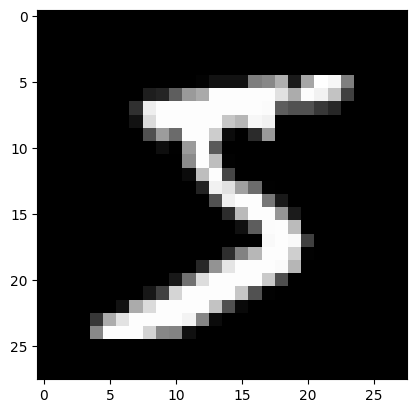

In [4]:
X_norm = (X / 255.0)
X_rs = X_norm.reshape(-1,28,28)
print(X_rs.shape)
plt.imshow(X_rs[0], cmap='gray')

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_rs, y, test_size=0.2, random_state=42
)

In [6]:
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (56000, 28, 28)
Test shape: (14000, 28, 28)


## CNN

In [ ]:
class ConvolutionLayer:
    def __init__(self, num_filters):
        self.num_filters = num_filters

        # Better weight initialization
        self.filters = np.random.randn(num_filters, 3, 3) / 9

    def forward(self, input_image):
        h, w = input_image.shape
        output = np.zeros((h-2, w-2, self.num_filters))

        for i in range(h-2):
            for j in range(w-2):
                region = input_image[i:(i+3), j:(j+3)]
                output[i, j] = np.sum(region * self.filters, axis=(1,2))

        return output

In [8]:
class MaxPooling:
    def forward(self, input_data):
        h ,w, num_filters = input_data.shape
        output = np.zeros((h//2, w//2, num_filters))

        for i in range(0, h//2):
            for j in range(0 , w//2):
                region = input_data[(i*2):(i*2+2), (j*2):(j*2+2)]
                output[i, j] = np.max(region, axis=(0, 1))
        return output

def relu(x):
    return np.maximum(0, x)

In [9]:
class DenseLayer:
    def __init__(self, input_len, nodes):
        self.weights = np.random.randn(input_len, nodes) / input_len
        self.bias = np.zeros(nodes)

    def forward(self, input):
        self.last_input = input
        return np.dot(input, self.weights) + self.bias

def softmax(x):
    exp_x = np.exp(x - np.max(x)) # Subtract max for numerical stability
    return exp_x / exp_x.sum()

In [10]:
# Initialize layers
conv = ConvolutionLayer(32)
pool = MaxPooling()
dense = DenseLayer(13 * 13 * 32, 10)        # corrected input size

def forward_pass(image):
    # Pass through layers
    out = conv.forward(image)
    out = relu(out)
    out = pool.forward(out)
    out = out.flatten()                     # Flatten
    out = dense.forward(out)
    out = softmax(out)                      # Final probabilities
    return out

# Test with one image
prediction = forward_pass(X_train[0])
print(f"Predicted probabilities: {prediction}")
print(f"Predicted class: {np.argmax(prediction)}")

Predicted probabilities: [0.09993844 0.0999457  0.10023072 0.09999198 0.10002242 0.0999409
 0.09988386 0.10009742 0.09983684 0.10011173]
Predicted class: 2


In [11]:
def cross_entropy_loss(probs, true_label):
    # true_label is an integer (e.g., 7), probs is an array of 10 probabilities
    # We add a tiny epsilon to avoid log(0) which is undefined
    epsilon = 1e-12
    return -np.log(probs[int(true_label)] + epsilon)

In [12]:
def train(X, y, epochs=16, lr=0.005):
    for epoch in range(epochs):
        print(f"--- Epoch {epoch + 1} ---")

        # Shuffle data
        perm = np.random.permutation(len(X))
        X = X[perm]
        y = y[perm]

        loss = 0
        num_correct = 0

        for i, (image, label) in enumerate(zip(X, y)):

            # 1. Forward pass
            probs = forward_pass(image)

            # 2. Compute loss
            loss += cross_entropy_loss(probs, label)

            # 3. Accuracy
            if np.argmax(probs) == int(label):
                num_correct += 1

            # 4. Compute gradient
            gradient = probs.copy()
            gradient[int(label)] -= 1

            # 5. Update dense layer
            dense.weights -= lr * np.outer(dense.last_input, gradient)
            dense.bias -= lr * gradient

            # Print progress
            if i % 1000 == 999:
                print(f"Step {i+1}: Avg Loss {loss/1000:.3f} | Accuracy: {num_correct/1000:.2%}")
                loss = 0
                num_correct = 0

In [13]:
train(X_train, y_train)

--- Epoch 1 ---
Step 1000: Avg Loss 1.387 | Accuracy: 64.80%
Step 2000: Avg Loss 0.747 | Accuracy: 84.00%
Step 3000: Avg Loss 0.642 | Accuracy: 83.90%
Step 4000: Avg Loss 0.572 | Accuracy: 85.20%
Step 5000: Avg Loss 0.495 | Accuracy: 87.40%
Step 6000: Avg Loss 0.488 | Accuracy: 87.20%
Step 7000: Avg Loss 0.483 | Accuracy: 86.60%
Step 8000: Avg Loss 0.404 | Accuracy: 89.30%
Step 9000: Avg Loss 0.383 | Accuracy: 90.30%
Step 10000: Avg Loss 0.375 | Accuracy: 90.30%
Step 11000: Avg Loss 0.417 | Accuracy: 89.00%
Step 12000: Avg Loss 0.393 | Accuracy: 88.60%
Step 13000: Avg Loss 0.350 | Accuracy: 90.30%
Step 14000: Avg Loss 0.316 | Accuracy: 90.50%
Step 15000: Avg Loss 0.369 | Accuracy: 89.20%
Step 16000: Avg Loss 0.352 | Accuracy: 89.40%
Step 17000: Avg Loss 0.333 | Accuracy: 91.80%
Step 18000: Avg Loss 0.358 | Accuracy: 90.10%
Step 19000: Avg Loss 0.283 | Accuracy: 93.00%
Step 20000: Avg Loss 0.334 | Accuracy: 90.30%
Step 21000: Avg Loss 0.345 | Accuracy: 90.20%
Step 22000: Avg Loss 0.356 

In [14]:
def evaluate(X, y):
    num_correct = 0
    total_loss = 0

    print(f"Evaluating on {len(X)} test samples...")

    for image, label in zip(X, y):
        # 1. Forward pass
        probs = forward_pass(image)

        # 2. Track accuracy
        if np.argmax(probs) == int(label):
            num_correct += 1

        # 3. Track loss
        total_loss += cross_entropy_loss(probs, label)

    accuracy = num_correct / len(X)
    avg_loss = total_loss / len(X)

    print(f"Test Accuracy: {accuracy:.2%}")
    print(f"Average Test Loss: {avg_loss:.4f}")
    return accuracy

# Run it on your test set
test_acc = evaluate(X_test[:200], y_test[:200])
print(test_acc)


Evaluating on 200 test samples...
Test Accuracy: 99.00%
Average Test Loss: 0.0704
0.99


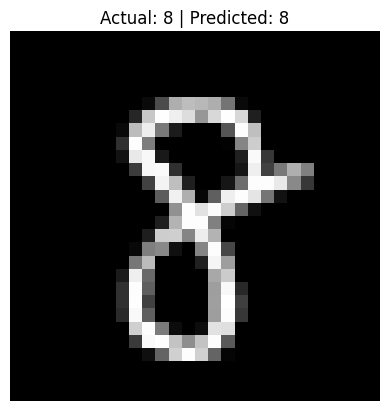

In [15]:
### import matplotlib.pyplot as plt

# Pick a random sample from the test set
idx = 13
img = X_test[idx]
actual_label = y_test[idx]

# Get prediction
probs = forward_pass(img)
predicted_label = np.argmax(probs)

# Plot
plt.imshow(img, cmap='gray')
plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}")
plt.axis('off')
plt.show()